* * *
<pre> Formation Machine Learning            <i> Jour 1 - Apprentissage supervisé</i></pre>
* * *

<h1 align="center"> TP1 : de la régression linéaire à la classification </h1>

<pre align="left"> Auteur : Igor Colin </pre>
* * *

##### Objectifs de la séance
- Manipuler le triptyque **`fit` / `predict` / `score`** commun à tous les modèles `scikit-learn`.
- Passer en revue, du plus simple au plus riche : **régression linéaire**, un **perceptron codé à la main** (descente de gradient), les approches **générative** (LDA/QDA) et **discriminative** (régression logistique).
- Savoir **évaluer et sélectionner** un modèle (validation croisée, sur/sous-apprentissage, ROC/AUC).
- Constater qu'un même outil s'applique à des données très différentes : tableaux, images, texte.

Le notebook est à trous : complétez les blocs marqués `# À COMPLÉTER`. La cellule suivante installe le décor.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, validation_curve

np.random.seed(0)
plt.rcParams["figure.figsize"] = (6, 4)
print("Environnement prêt.")

Environnement prêt.


## 1. Prise en main

On charge le jeu **Breast Cancer Wisconsin** : 569 tumeurs décrites par 30 mesures (rayon, texture, etc.), à classer en *bénigne* (1) ou *maligne* (0). C'est un problème tabulaire binaire, typique d'un cas métier.

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target
print("X :", X.shape, "| classes :", dict(zip(*np.unique(y, return_counts=True))))
print("4 premières variables :", list(data.feature_names[:4]))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)
print("train :", X_train.shape[0], "| test :", X_test.shape[0])

X : (569, 30) | classes : {0: 212, 1: 357}
4 premières variables : ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
train : 398 | test : 171


Tout modèle `scikit-learn` suit la même interface : on l'instancie, on l'entraîne avec `.fit(X_train, y_train)`, on prédit avec `.predict(...)` et on mesure avec `.score(...)`.

### Exercice 1
Entraînez un **k plus proches voisins** (`KNeighborsClassifier`, `k=5`) et affichez sa précision (*accuracy*) sur le jeu de test.

In [3]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
acc = knn.score(X_test, y_test)
print(f"Accuracy kNN (k=5) : {acc:.3f}")

Accuracy kNN (k=5) : 0.947


Le kNN ne fait aucune hypothèse sur la forme de la frontière : c'est une bonne *référence* (baseline). Dans la suite on introduit des modèles **paramétriques**, plus rapides à prédire et plus interprétables.

## 2. Régression linéaire

On commence par la **régression** : la cible est continue. Une droite (ou un hyperplan) $\hat y = w^\top x + b$ ajustée par moindres carrés.

### 2.1 Une seule variable
On fabrique un jeu jouet $y = 3x + 2 + \text{bruit}$ pour visualiser.

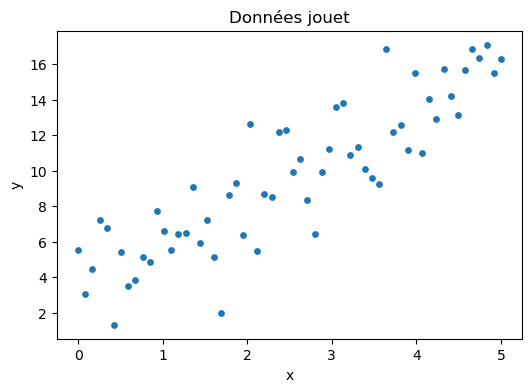

In [4]:
x = np.linspace(0, 5, 60)
y_lin = 3 * x + 2 + np.random.normal(0, 2, size=x.size)
X1 = x.reshape(-1, 1)   # scikit-learn attend une matrice (n, d)

plt.scatter(x, y_lin, s=15)
plt.xlabel("x"); plt.ylabel("y"); plt.title("Données jouet"); plt.show()

### Exercice 2
Ajustez une `LinearRegression`, récupérez la pente (`coef_`) et l'ordonnée à l'origine (`intercept_`), puis tracez la droite estimée.

pente estimée = 2.48 (vrai 3) | ordo = 3.44 (vrai 2)


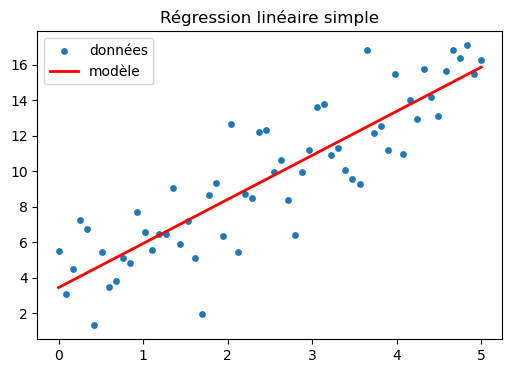

In [5]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X1, y_lin)
pente, ordo = reg.coef_[0], reg.intercept_
print(f"pente estimée = {pente:.2f} (vrai 3) | ordo = {ordo:.2f} (vrai 2)")

plt.scatter(x, y_lin, s=15, label="données")
plt.plot(x, reg.predict(X1), "r-", lw=2, label="modèle")
plt.legend(); plt.title("Régression linéaire simple"); plt.show()

### 2.2 Régression multiple (jeu Diabetes)
442 patients, 10 variables physiologiques (âge, IMC, pression...), cible = progression de la maladie à un an. On mesure la qualité par le **R²** (1 = parfait, 0 = aussi bon que prédire la moyenne).

In [6]:
from sklearn.datasets import load_diabetes

db = load_diabetes()
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    db.data, db.target, test_size=0.3, random_state=0)
print("variables :", list(db.feature_names))

variables : ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


### Exercice 3
Ajustez une régression linéaire, affichez le **R² en test**, et identifiez les deux variables au coefficient le plus fort (en valeur absolue). *Les variables Diabetes sont déjà standardisées, donc les coefficients sont comparables entre eux.*

In [7]:
reg_d = LinearRegression().fit(Xd_train, yd_train)
r2 = reg_d.score(Xd_test, yd_test)
print(f"R² test = {r2:.3f}")

ordre = np.argsort(np.abs(reg_d.coef_))[::-1]
print("Variables les plus influentes :")
for i in ordre[:2]:
    print(f"  {db.feature_names[i]:>4} : coef = {reg_d.coef_[i]:+.1f}")

R² test = 0.393
Variables les plus influentes :
    s5 : coef = +721.9
   bmi : coef = +579.5


Un R² sur un seul découpage train/test est bruité. La **validation croisée** moyenne la performance sur plusieurs découpages.

### Exercice 4
Calculez le R² moyen et son écart-type par validation croisée à 5 plis (`cross_val_score`, `scoring="r2"`).

In [8]:
scores = cross_val_score(LinearRegression(), db.data, db.target, cv=5, scoring="r2")
print(f"R² = {scores.mean():.3f} +/- {scores.std():.3f}")

R² = 0.482 +/- 0.049


## 3. Le perceptron codé à la main

On passe à la **classification** et on regarde *sous le capot* d'un modèle linéaire : on optimise nous-même les paramètres par **descente de gradient**. C'est le pont direct avec la théorie du matin.

Un perceptron prédit le signe d'une fonction linéaire $f(x) = w^\top x + \theta$. Avec des étiquettes $y \in \{-1, +1\}$, on minimise la perte

$$\mathcal{L}(w,\theta) = \frac{1}{n}\sum_{i=1}^n \max\!\big(0,\; -y_i\,(w^\top x_i + \theta)\big).$$

Un point bien classé a une marge $y_i(w^\top x_i+\theta) > 0$ et ne contribue pas. Pour un point **mal classé**, le (sous-)gradient vaut $-y_i x_i$ pour $w$ et $-y_i$ pour $\theta$.

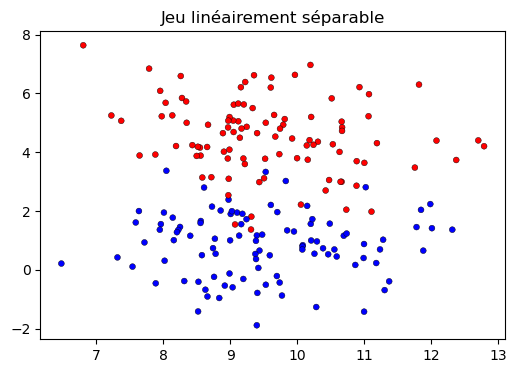

In [9]:
from sklearn.datasets import make_blobs

Xb, yb = make_blobs(n_samples=200, centers=2, cluster_std=1.2, random_state=4)
yb = np.where(yb == 0, -1, 1)   # étiquettes dans {-1, +1}

plt.scatter(Xb[:, 0], Xb[:, 1], c=yb, cmap="bwr", s=18, edgecolor="k", linewidth=.3)
plt.title("Jeu linéairement séparable"); plt.show()

### Exercice 5
Complétez la descente de gradient. À chaque itération, on **parcourt les points un par un** : on calcule la marge $y_i(w^\top x_i + \theta)$, et si le point est mal classé (marge $\le 0$) on ajoute sa contribution au gradient. Une seule mise à jour de `w` et `theta` à la fin du balayage.

In [10]:
def entraine_perceptron(X, y, lr=0.01, n_iter=60):
    n, d = X.shape
    w, theta, pertes = np.zeros(d), 0.0, []
    for _ in range(n_iter):
        grad_w, grad_theta, perte = np.zeros(d), 0.0, 0.0
        for i in range(n):
            marge = y[i] * (w @ X[i] + theta)
            if marge <= 0:                 # point mal classé
                perte += -marge
                grad_w += -y[i] * X[i]
                grad_theta += -y[i]
        w = w - lr * grad_w / n
        theta = theta - lr * grad_theta / n
        pertes.append(perte / n)
    return w, theta, pertes

w, theta, pertes = entraine_perceptron(Xb, yb)
print("w =", np.round(w, 3), "| theta =", round(theta, 3))

w = [-0.017  0.068] | theta = -0.004


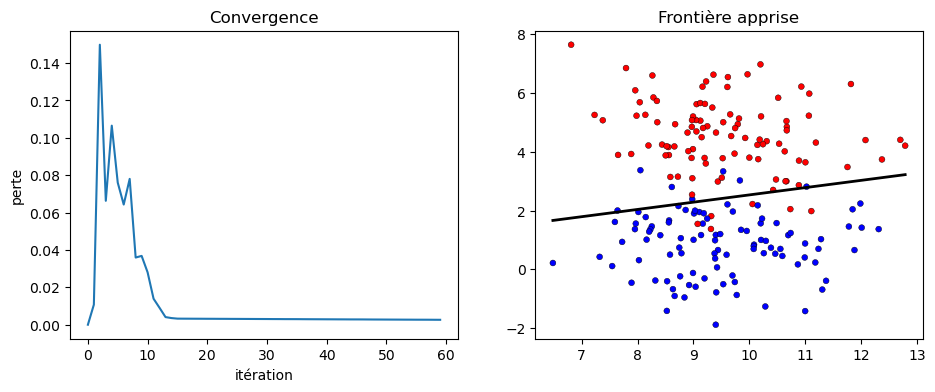

In [11]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(pertes); a1.set_xlabel("itération"); a1.set_ylabel("perte"); a1.set_title("Convergence")

a2.scatter(Xb[:, 0], Xb[:, 1], c=yb, cmap="bwr", s=18, edgecolor="k", linewidth=.3)
xx = np.array([Xb[:, 0].min(), Xb[:, 0].max()])
a2.plot(xx, -(w[0] * xx + theta) / w[1], "k-", lw=2)   # w0 x + w1 y + theta = 0
a2.set_title("Frontière apprise"); plt.show()

### Exercice 6
Le **pas d'apprentissage** `lr` contrôle la vitesse de convergence. Tracez la courbe de perte pour `lr` dans `{0.001, 0.01, 0.1}` et commentez.

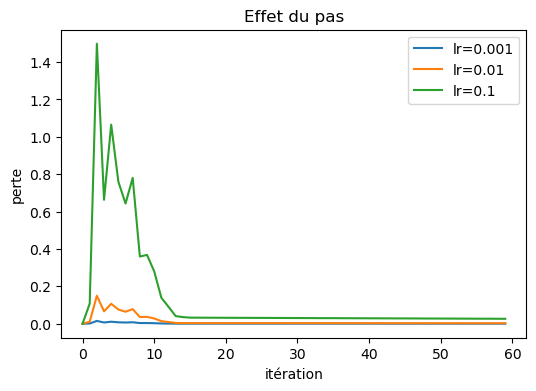

In [12]:
for lr in [0.001, 0.01, 0.1]:
    _, _, p = entraine_perceptron(Xb, yb, lr=lr)
    plt.plot(p, label=f"lr={lr}")
plt.xlabel("itération"); plt.ylabel("perte"); plt.legend(); plt.title("Effet du pas"); plt.show()

En pratique on n'écrit pas la descente à la main : `sklearn` fournit `Perceptron` et `SGDClassifier` (mêmes idées, optimisées). On les retrouve via l'interface `fit`/`predict` habituelle.

## 4. LDA, QDA et régression logistique

Deux familles pour la classification :
- **Générative** (LDA/QDA) : on modélise la distribution de chaque classe $p(x\mid y)$ (ici gaussienne), puis on retourne le tout par Bayes. LDA suppose une covariance commune, d'où une frontière **linéaire** ; QDA autorise une covariance par classe, d'où une frontière **quadratique**.
- **Discriminative** (régression logistique) : on modélise directement $p(y\mid x)$ sans hypothèse sur la forme des classes.

On illustre sur deux gaussiennes 2D.

In [13]:
from sklearn.datasets import make_classification

Xc, yc = make_classification(n_samples=300, n_features=2, n_redundant=0,
                             n_clusters_per_class=1, class_sep=1.0, random_state=2)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.3, random_state=0)

def trace_frontiere(model, X, y, ax, titre):
    h = .05
    x0, x1 = X[:, 0].min() - .5, X[:, 0].max() + .5
    y0, y1 = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x0, x1, h), np.arange(y0, y1, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=.25, cmap="bwr")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", s=14, edgecolor="k", linewidth=.3)
    ax.set_title(titre)

### Exercice 7
Entraînez les trois modèles (`LinearDiscriminantAnalysis`, `QuadraticDiscriminantAnalysis`, `LogisticRegression`) sur le jeu d'entraînement et complétez le dictionnaire `modeles`.

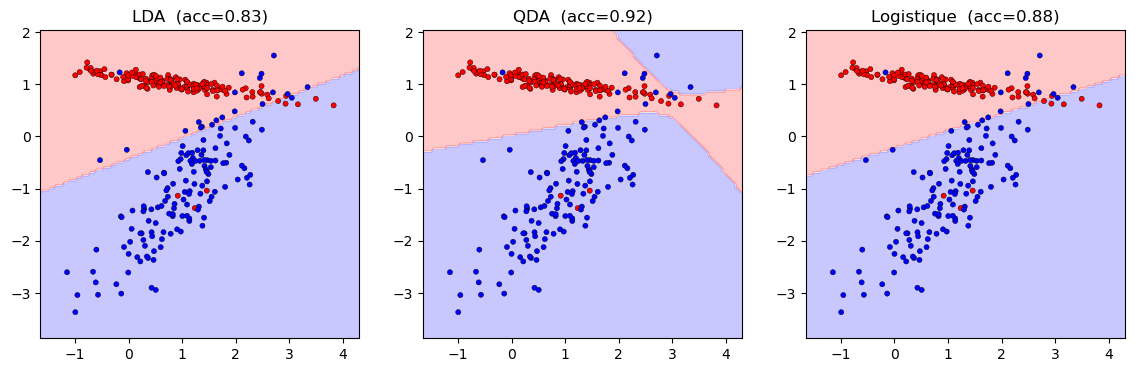

In [14]:
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis)
from sklearn.linear_model import LogisticRegression

modeles = {
    "LDA": LinearDiscriminantAnalysis().fit(Xc_tr, yc_tr),
    "QDA": QuadraticDiscriminantAnalysis().fit(Xc_tr, yc_tr),
    "Logistique": LogisticRegression().fit(Xc_tr, yc_tr),
}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for (nom, m), ax in zip(modeles.items(), axes):
    trace_frontiere(m, Xc, yc, ax, f"{nom}  (acc={m.score(Xc_te, yc_te):.2f})")
plt.show()

La régression logistique fournit aussi des **probabilités** (`predict_proba`), précieuses pour fixer un seuil de décision selon le coût des erreurs.

In [15]:
logit = modeles["Logistique"]
proba = logit.predict_proba(Xc_te[:5])[:, 1]
for p, vrai in zip(proba, yc_te[:5]):
    print(f"P(classe 1) = {p:.2f}  | vraie classe = {vrai}")

P(classe 1) = 0.02  | vraie classe = 0
P(classe 1) = 0.98  | vraie classe = 1
P(classe 1) = 0.95  | vraie classe = 1
P(classe 1) = 0.00  | vraie classe = 0
P(classe 1) = 0.95  | vraie classe = 1


## 5. Sur-apprentissage et sous-apprentissage

Un modèle peut coller *trop* aux données d'entraînement et capturer le bruit : c'est le **sur-apprentissage** (overfitting). À l'inverse, un modèle trop rigide rate la structure : c'est le **sous-apprentissage** (underfitting). Le kNN l'illustre parfaitement : `k=1` recopie chaque point (frontière hachée, qui suit le bruit), un `k` très grand lisse à l'excès.

On reprend le tracé de frontière `trace_frontiere` défini plus haut, sur un jeu volontairement bruité.

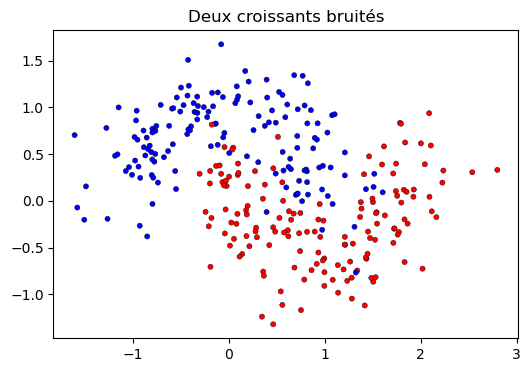

In [16]:
from sklearn.datasets import make_moons

Xm, ym = make_moons(n_samples=300, noise=0.30, random_state=0)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.3, random_state=0)

plt.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap="bwr", s=14, edgecolor="k", linewidth=.3)
plt.title("Deux croissants bruités"); plt.show()

### Exercice 8
Pour `k` dans `[1, 15, 100]`, entraînez un `KNeighborsClassifier` et tracez sa frontière de décision avec `trace_frontiere`. Observez la frontière hachée de `k=1` (sur-apprentissage) et celle, trop lisse, de `k=100`.

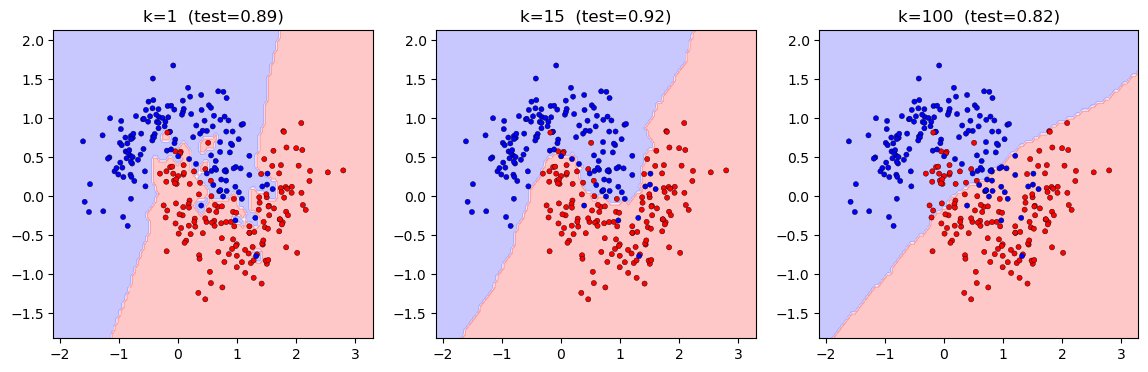

In [17]:
from sklearn.neighbors import KNeighborsClassifier

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for k, ax in zip([1, 15, 100], axes):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(Xm_tr, ym_tr)
    trace_frontiere(knn_k, Xm, ym, ax,
                    f"k={k}  (test={knn_k.score(Xm_te, ym_te):.2f})")
plt.show()

Pour situer le bon compromis, on trace l'**accuracy d'entraînement et de test en fonction de `k`**. Avec le kNN, la complexité du modèle **décroît** quand `k` augmente : `k=1` est le modèle le plus complexe.

### Exercice 9
Complétez la boucle qui calcule, pour chaque `k`, l'accuracy sur l'entraînement et sur le test.

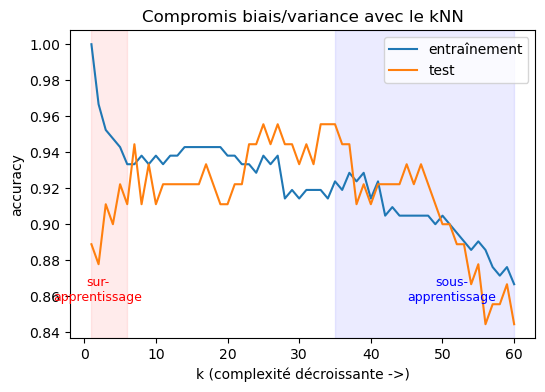

In [18]:
ks = range(1, 61)
acc_tr, acc_te = [], []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=k).fit(Xm_tr, ym_tr)
    acc_tr.append(m.score(Xm_tr, ym_tr))
    acc_te.append(m.score(Xm_te, ym_te))

ax = plt.gca()
ax.plot(list(ks), acc_tr, label="entraînement")
ax.plot(list(ks), acc_te, label="test")
ax.axvspan(1, 6, color="red", alpha=.08)
ax.axvspan(35, 60, color="blue", alpha=.08)
ax.text(0.06, 0.12, "sur-\napprentissage", transform=ax.transAxes,
        color="red", ha="center", fontsize=9)
ax.text(0.82, 0.12, "sous-\napprentissage", transform=ax.transAxes,
        color="blue", ha="center", fontsize=9)
ax.set_xlabel("k (complexité décroissante ->)"); ax.set_ylabel("accuracy")
ax.legend(); ax.set_title("Compromis biais/variance avec le kNN"); plt.show()

À gauche (`k` petit) l'accuracy d'entraînement est quasi parfaite mais celle de test décroche : le modèle apprend le bruit. À droite (`k` grand) les deux baissent : le modèle est trop simple. Le meilleur `k` se lit au sommet de la courbe de **test**.

## 6. Évaluation et sélection de modèle

L'*accuracy* ne suffit pas, surtout si les classes sont déséquilibrées. On regarde la **matrice de confusion**, le **rapport de classification** (précision, rappel, f1) et la courbe **ROC** (aire AUC).

On revient au jeu Breast Cancer.

### Exercice 10
On enchaîne standardisation et régression logistique dans un `Pipeline` (la standardisation aide la convergence). Entraînez-le, puis affichez la matrice de confusion et le rapport de classification sur le test.

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=data.target_names))

[[ 60   3]
 [  1 107]]
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.97        63
      benign       0.97      0.99      0.98       108

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



AUC = 0.994


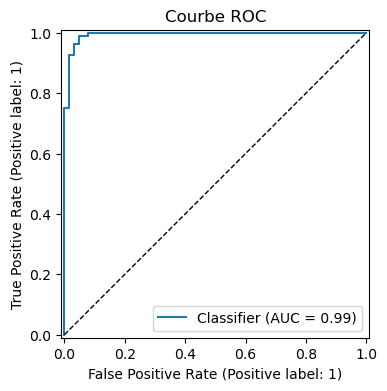

In [20]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

proba_test = clf.predict_proba(X_test)[:, 1]
print(f"AUC = {roc_auc_score(y_test, proba_test):.3f}")
RocCurveDisplay.from_predictions(y_test, proba_test)
plt.plot([0, 1], [0, 1], "k--", lw=1); plt.title("Courbe ROC"); plt.show()

Enfin, le **compromis biais/variance** : un modèle trop simple sous-apprend, trop complexe sur-apprend. La **courbe de validation** trace la performance d'entraînement et de validation en fonction d'un hyperparamètre. Ici la régularisation `C` de la régression logistique (petit `C` = forte régularisation = modèle simple).

### Exercice 11
On réutilise le pipeline `clf` (standardisation + logistique). Dans un pipeline, l'hyperparamètre `C` de la logistique se nomme `"logisticregression__C"`. Complétez `param_name` et `param_range`.

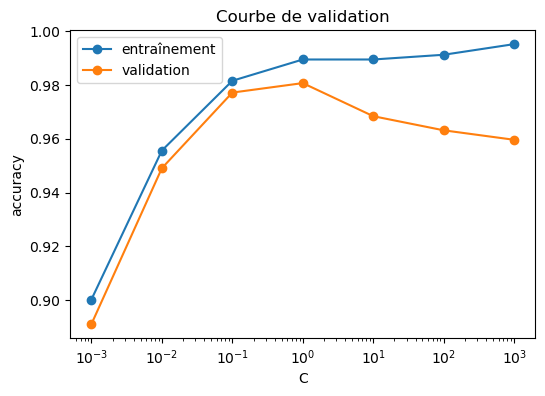

In [21]:
Cs = np.logspace(-3, 3, 7)
tr, va = validation_curve(
    clf, X, y,
    param_name="logisticregression__C", param_range=Cs, cv=5)
plt.semilogx(Cs, tr.mean(1), "o-", label="entraînement")
plt.semilogx(Cs, va.mean(1), "o-", label="validation")
plt.xlabel("C"); plt.ylabel("accuracy"); plt.legend()
plt.title("Courbe de validation"); plt.show()

Sur un cas métier, on choisit la métrique selon l'enjeu : en dépistage médical on privilégie le **rappel** (ne pas rater un cas positif), quitte à accepter de fausses alertes. Pour des classes déséquilibrées, pensez à `class_weight="balanced"`.

## 7. Tableaux, images et texte

La même chaîne `StandardScaler -> LogisticRegression`, encapsulée dans un `Pipeline`, s'applique à des tableaux, des images et du texte. Seule la *représentation* des données change.

In [22]:
# (a) Données tabulaires : Breast Cancer
pipe_tab = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
pipe_tab.fit(X_train, y_train)
print(f"[Tabulaire] accuracy = {pipe_tab.score(X_test, y_test):.3f}")

[Tabulaire] accuracy = 0.977


### Exercice 12
**Images** : le jeu `load_digits` (1797 chiffres manuscrits 8x8). Construisez un pipeline `StandardScaler -> LogisticRegression` et évaluez-le.

[Images] accuracy = 0.961


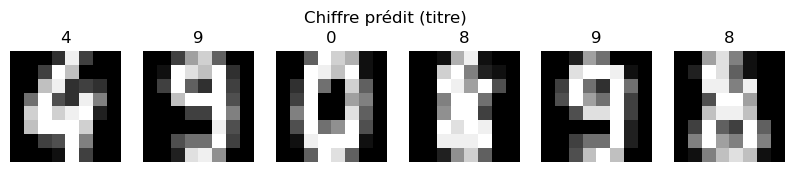

In [23]:
from sklearn.datasets import load_digits

dig = load_digits()
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(
    dig.data, dig.target, test_size=0.3, random_state=0)

pipe_img = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
pipe_img.fit(Xi_tr, yi_tr)
print(f"[Images] accuracy = {pipe_img.score(Xi_te, yi_te):.3f}")

fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for ax, img, vec in zip(axes, dig.images[-6:], dig.data[-6:]):
    ax.imshow(img, cmap="gray"); ax.axis("off")
    ax.set_title(pipe_img.predict([vec])[0])
plt.suptitle("Chiffre prédit (titre)"); plt.show()

### Du texte vers des vecteurs : TF-IDF

Un modèle ne sait manipuler que des **vecteurs de nombres**, pas du texte brut : il faut donc transformer chaque message en vecteur.

L'approche la plus simple est le **sac de mots** (*bag of words*) : on liste tous les mots du corpus (le vocabulaire), et chaque message devient un vecteur qui compte combien de fois chaque mot y apparaît. On perd l'ordre des mots, mais c'est souvent suffisant pour classer.

Souci : les mots très fréquents (« le », « de », « vous ») écrasent tout alors qu'ils sont peu informatifs. Le **TF-IDF** corrige ça en pondérant chaque mot par deux facteurs : sa fréquence dans le message (**TF**) multipliée par l'inverse de sa fréquence dans le corpus (**IDF**). Un mot présent partout reçoit un poids faible ; un mot rare et **discriminant** (« cliquez », « facture ») reçoit un poids fort. `TfidfVectorizer` enchaîne les deux étapes (vocabulaire + pondération) d'un coup. Illustration sur trois phrases :

In [24]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

demo = ["offre gratuite cliquez ici",
        "réunion projet demain matin",
        "cliquez pour votre cadeau gratuit"]
demo_vec = TfidfVectorizer().fit(demo)
pd.DataFrame(demo_vec.transform(demo).toarray().round(2),
             columns=demo_vec.get_feature_names_out(),
             index=["phrase 1", "phrase 2", "phrase 3"])

,cadeau,cliquez,demain,gratuit,gratuite,ici,matin,offre,pour,projet,réunion,votre
phrase 1,0.00,0.40,0.0,0.00,0.53,0.53,0.0,0.53,0.00,0.0,0.0,0.00
phrase 2,0.00,0.00,0.5,0.00,0.00,0.00,0.5,0.00,0.00,0.5,0.5,0.00
phrase 3,0.47,0.36,0.0,0.47,0.00,0.00,0.0,0.00,0.47,0.0,0.0,0.47


Chaque ligne est un vecteur, chaque colonne un mot du vocabulaire ; les poids forts repèrent les mots caractéristiques de chaque phrase. On applique maintenant cette idée à un vrai jeu de données.

### Exercice 13
**Texte** : on charge un vrai jeu de 400 messages (`messages_fr.csv`, colonnes `message` et `label`), on le sépare en train/test, on vectorise en **TF-IDF** et on entraîne une régression logistique. Complétez l'entraînement du pipeline et l'accuracy sur le test.

In [25]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

msgs = pd.read_csv("messages_fr.csv")
print("jeu :", msgs.shape, "|", msgs["label"].value_counts().to_dict())
msgs.sample(4, random_state=1)

jeu : (400, 2) | {'ham': 200, 'spam': 200}


,message,label
398,"Attention argent facile et rapide, aucune comp...",spam
125,"hello urgent : le serveur de prod est tombé, r...",ham
328,salut tu peux récupérer le colis à la poste de...,ham
339,bonjour la deadline du livrable est repoussée ...,ham


In [26]:
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    msgs["message"], msgs["label"], test_size=0.3, random_state=0, stratify=msgs["label"])

pipe_txt = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000))
pipe_txt.fit(Xt_tr, yt_tr)
acc = pipe_txt.score(Xt_te, yt_te)
print(f"[Texte] accuracy = {acc:.3f}")

nouveaux = ["gagnez de l'argent gratuit, cliquez ici", "tu es dispo pour le point projet demain"]
for m, p in zip(nouveaux, pipe_txt.predict(nouveaux)):
    print(f"[{p.upper():>4}] {m}")

[Texte] accuracy = 1.000
[SPAM] gagnez de l'argent gratuit, cliquez ici
[ HAM] tu es dispo pour le point projet demain


*Bonus* : on peut lire les mots les plus « spam » appris par le modèle en regardant les plus gros coefficients de la régression logistique.

In [27]:
import numpy as np
vec = pipe_txt.named_steps["tfidfvectorizer"]
coef = pipe_txt.named_steps["logisticregression"].coef_[0]
mots = np.array(vec.get_feature_names_out())
top = np.argsort(coef)[::-1][:10]
print("mots les plus indicatifs de SPAM :", ", ".join(mots[top]))

mots les plus indicatifs de SPAM : vous, cliquez, votre, et, répondez, ici, sans, maintenant, offre, cadeau


## Bilan du jour 1

- Tous les modèles partagent l'interface **`fit` / `predict` / `score`**.
- La **régression** prédit une valeur continue ; la **classification** une étiquette (avec, pour la logistique, une probabilité).
- Coder un **perceptron** montre qu'apprendre = **minimiser une perte par descente de gradient**.
- Approches **générative** (LDA/QDA) vs **discriminative** (logistique) : hypothèses différentes, frontières différentes.
- On **évalue** avec validation croisée, matrice de confusion, ROC/AUC, et on surveille le **compromis biais/variance**.
- Un même pipeline s'applique à des **tableaux, images, texte** : seule la représentation change.

Demain : apprentissage **non supervisé** (clustering, réduction de dimension) et extensions (anomalies, recommandation, réseaux de neurones).